In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load Kenya data
df = pd.read_csv('../data/kenya.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (4108, 12)
Columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [3]:
# Add country name
df['Country'] = 'Kenya'

# Replace -999 with NaN
df = df.replace(-999, np.nan)

print("Missing values after replacing -999:")
print(df.isna().sum())

Missing values after replacing -999:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64


In [4]:
# Convert YEAR and DOY to datetime
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')

# Extract month and year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df[['YEAR', 'DOY', 'Date', 'Month']].head()

Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [5]:
# Check and remove duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Dropped {duplicates} duplicates. New shape: {df.shape}")
else:
    print("No duplicates found.")

Number of duplicate rows: 0
No duplicates found.


In [6]:
# Summary statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month,Year
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,6.423564,2020.131451
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,3.477046,3.248907
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,1.000000,2015.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,3.000000,2017.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,6.000000,2020.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,9.000000,2023.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,12.000000,2026.000000


In [7]:
# Missing values report
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Percentage', ascending=False)

print("Columns with missing values:")
missing_report

Columns with missing values:


,Missing Count,Percentage


In [8]:
# Handle missing values using forward fill
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

for col in weather_cols:
    if col in df.columns:
        df[col] = df[col].ffill()

remaining = df[weather_cols].isna().sum().sum()
print(f"Remaining missing values after forward fill: {remaining}")

Remaining missing values after forward fill: 0


In [9]:
# Outlier detection
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

for col in outlier_cols:
    if col in df.columns:
        clean_data = df[col].dropna()
        if len(clean_data) > 0:
            z_scores = np.abs(stats.zscore(clean_data))
            outliers = (z_scores > 3).sum()
            print(f"{col}: {outliers} outliers detected")

print("\nNote: Outliers retained as they may represent real extreme weather events")

T2M: 8 outliers detected
T2M_MAX: 3 outliers detected
T2M_MIN: 9 outliers detected
PRECTOTCORR: 92 outliers detected
RH2M: 6 outliers detected
WS2M: 0 outliers detected
WS2M_MAX: 6 outliers detected

Note: Outliers retained as they may represent real extreme weather events


In [10]:
# Export cleaned data
df.to_csv('../data/kenya_clean.csv', index=False)
print("Cleaned data saved to: data/kenya_clean.csv")
print(f"Final shape: {df.shape}")

Cleaned data saved to: data/kenya_clean.csv
Final shape: (4108, 16)


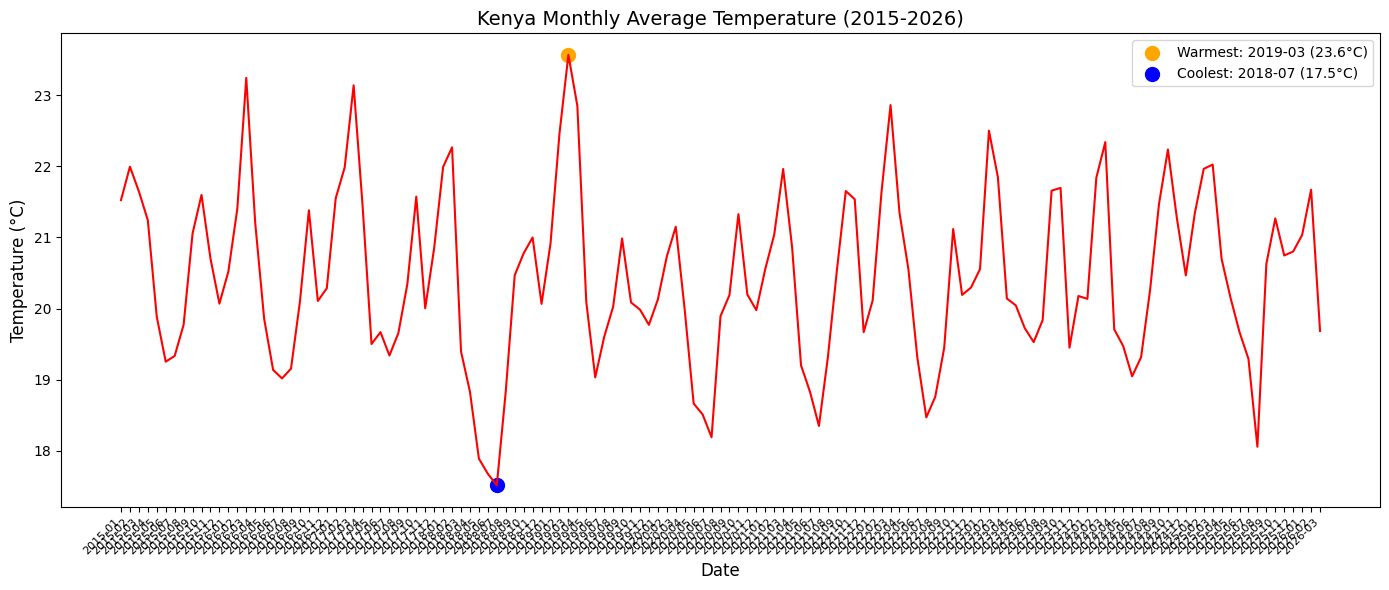

In [11]:
# Monthly temperature plot
monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_temp.index.astype(str), monthly_temp.values, linewidth=1.5, color='red')

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()
plt.scatter(str(warmest), monthly_temp.max(), color='orange', s=100, label=f'Warmest: {warmest} ({monthly_temp.max():.1f}°C)')
plt.scatter(str(coolest), monthly_temp.min(), color='blue', s=100, label=f'Coolest: {coolest} ({monthly_temp.min():.1f}°C)')

plt.title('Kenya Monthly Average Temperature (2015-2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

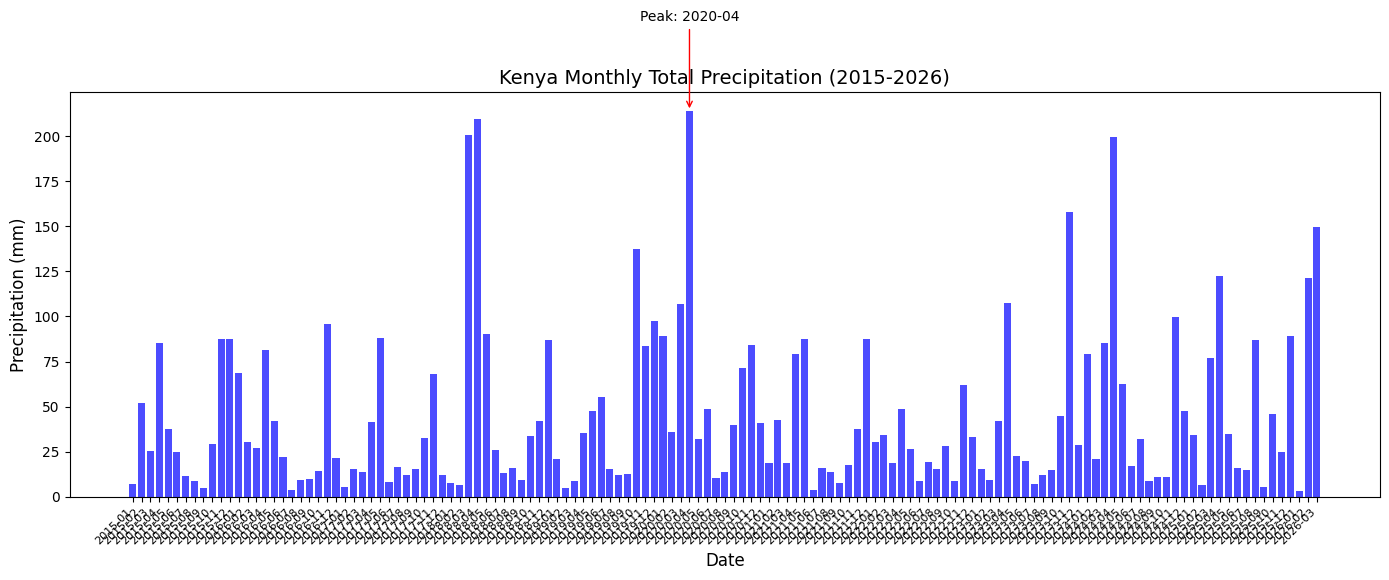

In [12]:
# Monthly precipitation
monthly_precip = df.groupby(df['Date'].dt.to_period('M'))['PRECTOTCORR'].sum()

plt.figure(figsize=(14, 6))
plt.bar(monthly_precip.index.astype(str), monthly_precip.values, color='blue', alpha=0.7)

peak_month = monthly_precip.idxmax()
peak_value = monthly_precip.max()
plt.annotate(f'Peak: {peak_month}', xy=(str(peak_month), peak_value), 
             xytext=(str(peak_month), peak_value + 50),
             ha='center', fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

plt.title('Kenya Monthly Total Precipitation (2015-2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

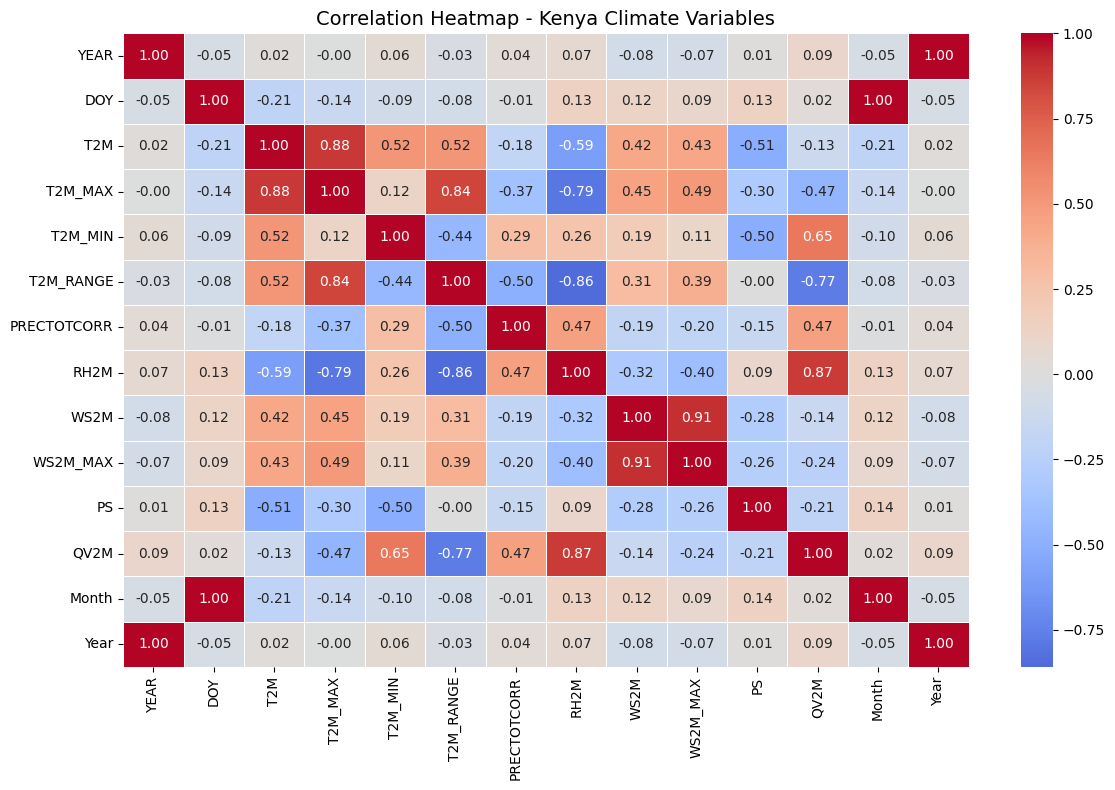


Top 3 strongest correlations:
Year      YEAR    1.000000
Month     DOY     0.996557
WS2M_MAX  WS2M    0.911457
dtype: float64


In [13]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Kenya Climate Variables', fontsize=14)
plt.tight_layout()
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corrs = upper.unstack().dropna().sort_values(ascending=False).head(3)
print("\nTop 3 strongest correlations:")
print(top_corrs)

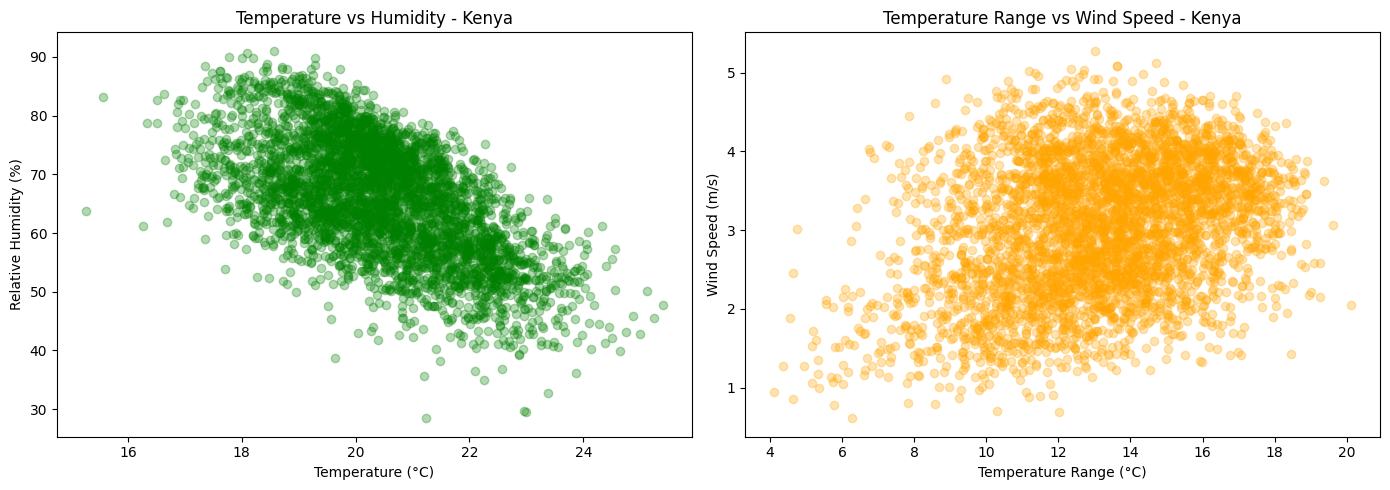

In [14]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.3, color='green')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Temperature vs Humidity - Kenya')

axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='orange')
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('Temperature Range vs Wind Speed - Kenya')

plt.tight_layout()
plt.show()

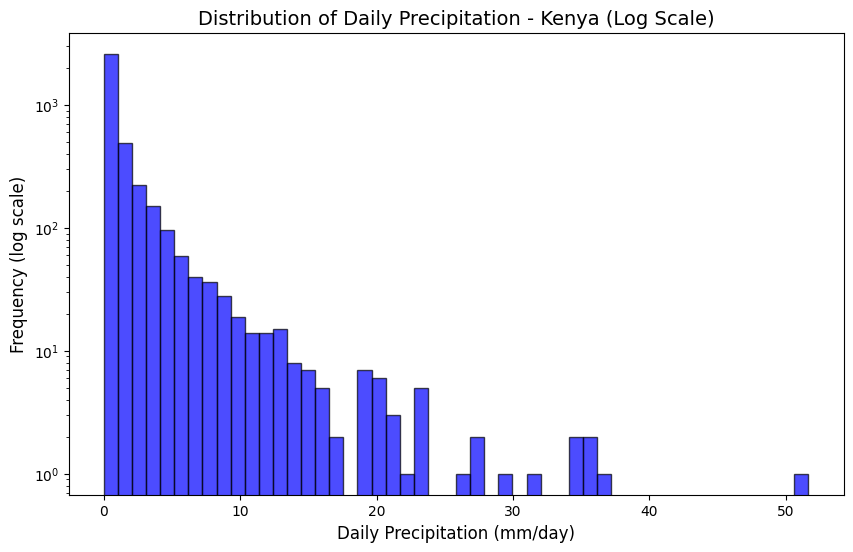

Most days have low precipitation (0-5 mm), with few extreme rainfall events


In [15]:
# Precipitation histogram
plt.figure(figsize=(10, 6))
precip_data = df['PRECTOTCORR'].dropna()
precip_data = precip_data[precip_data > 0]

plt.hist(precip_data, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.yscale('log')
plt.xlabel('Daily Precipitation (mm/day)', fontsize=12)
plt.ylabel('Frequency (log scale)', fontsize=12)
plt.title('Distribution of Daily Precipitation - Kenya (Log Scale)', fontsize=14)
plt.show()

print("Most days have low precipitation (0-5 mm), with few extreme rainfall events")